# Task 7 – Reverberation (Room Impulse Response)

Test how room acoustics (echo) affect speaker authentication by convolving
speech with room impulse responses (RIRs).

**RIR conditions (RT60 = time for 60 dB decay):**

| Condition | RT60 | Typical room |
|---|---|---|
| Dry | — | Anechoic (control) |
| Small | 0.2 s | Small office / bathroom |
| Medium | 0.5 s | Living room / classroom |
| Large | 1.0 s | Lecture hall / church |
| Very large | 2.0 s | Cathedral / sports hall |

**RIR source (priority order):**
1. WAV files in `data/rir/` — place RIRs from OpenSLR SLR28 here
2. **Synthetic RIRs** — exponentially-decaying noise model (automatic fallback, no download needed)

**Method:** `reverberant = speech ⊛ RIR` (linear convolution via FFT, trimmed to original length)

**Prerequisites:** `task1_baseline.ipynb` must have been run.

## 0. Setup

In [2]:
import sys, json, random
from pathlib import Path

SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt

from config import cfg
from embeddings import load_model, load_audio
from database import get_collection, list_enrolled
from threshold import compute_eer, compute_metrics_at_threshold, _load_enrolled_embeddings_bulk

RESULTS_DIR = cfg.paths.results_dir
TEST_DIR    = cfg.paths.test_dir
RANDOM_SEED = cfg.dataset.random_seed
SAMPLE_RATE = cfg.audio.sample_rate  # 16000

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_DIR}")

Results → D:\pwr\biometria\lab\voice\results


## 1. Load Task 1 baseline

In [3]:
task1_path = RESULTS_DIR / "task1_results.json"
if not task1_path.exists():
    raise FileNotFoundError("Run task1_baseline.ipynb first to generate task1_results.json")

with open(task1_path) as f:
    task1 = json.load(f)

eer_threshold = task1["eer_threshold"]
print(f"Task 1 baseline:")
print(f"  EER       = {task1['eer_pct']:.2f}%")
print(f"  Accuracy  = {task1['accuracy_at_eer_pct']:.2f}%")
print(f"  Threshold = {eer_threshold:.4f}")

Task 1 baseline:
  EER       = 0.11%
  Accuracy  = 99.89%
  Threshold = 0.3969


## 2. Prepare room impulse responses

Checks `data/rir/` for real RIR files (OpenSLR SLR28 format);
generates synthetic RIRs for any missing RT60 condition.

> **To use real RIRs:** download [OpenSLR SLR28](http://www.openslr.org/28/),
> extract `simulated_rirs/` and copy WAV files to `data/rir/`.
> Rename them as `rir_small.wav`, `rir_medium.wav`, `rir_large.wav`, `rir_very_large.wav`
> to override the corresponding synthetic RIR.

In [4]:
# (key, label, rt60_s, local_filename_hint)
RIR_CONFIGS = [
    ("small",      "Small room (RT60=0.2s)",   0.2, "rir_small.wav"),
    ("medium",     "Medium room (RT60=0.5s)",  0.5, "rir_medium.wav"),
    ("large",      "Large room (RT60=1.0s)",   1.0, "rir_large.wav"),
    ("very_large", "Very large (RT60=2.0s)",   2.0, "rir_very_large.wav"),
]

RIR_DIR = cfg.paths.data_dir / "rir"
RIR_DIR.mkdir(parents=True, exist_ok=True)


def generate_synthetic_rir(rt60: float, sr: int = SAMPLE_RATE) -> torch.Tensor:
    """
    Synthetic RIR via exponentially-decaying white noise.
    RT60 = time for signal to decay 60 dB (3 orders of magnitude in power).
    """
    n = max(512, int(rt60 * sr))
    t = np.arange(n, dtype=np.float32) / sr
    decay_rate = 6.908 / rt60  # ln(10^3) / RT60
    rir = np.random.randn(n).astype(np.float32) * np.exp(-decay_rate * t)
    rir[0] = 1.0  # direct sound impulse at t=0
    rir /= np.abs(rir).max()
    return torch.tensor(rir).unsqueeze(0)  # (1, N)


# Load or generate one RIR per condition
rir_waveforms: dict[str, torch.Tensor] = {}
rir_sources:   dict[str, str]         = {}

for key, label, rt60, hint in RIR_CONFIGS:
    local_path = RIR_DIR / hint
    if local_path.exists():
        w, sr_rir = torchaudio.load(str(local_path))
        if sr_rir != SAMPLE_RATE:
            w = torchaudio.functional.resample(w, sr_rir, SAMPLE_RATE)
        if w.shape[0] > 1:
            w = w.mean(dim=0, keepdim=True)
        rir_waveforms[key] = w
        rir_sources[key]   = f"local ({hint})"
    else:
        rir_waveforms[key] = generate_synthetic_rir(rt60)
        rir_sources[key]   = f"synthetic (RT60={rt60}s)"

for key, label, rt60, _ in RIR_CONFIGS:
    print(f"  {label:<30}  source: {rir_sources[key]}  len={rir_waveforms[key].shape[1]/SAMPLE_RATE:.2f}s")

  Small room (RT60=0.2s)          source: synthetic (RT60=0.2s)  len=0.20s
  Medium room (RT60=0.5s)         source: synthetic (RT60=0.5s)  len=0.50s
  Large room (RT60=1.0s)          source: synthetic (RT60=1.0s)  len=1.00s
  Very large (RT60=2.0s)          source: synthetic (RT60=2.0s)  len=2.00s


## 3. Visualize RIRs

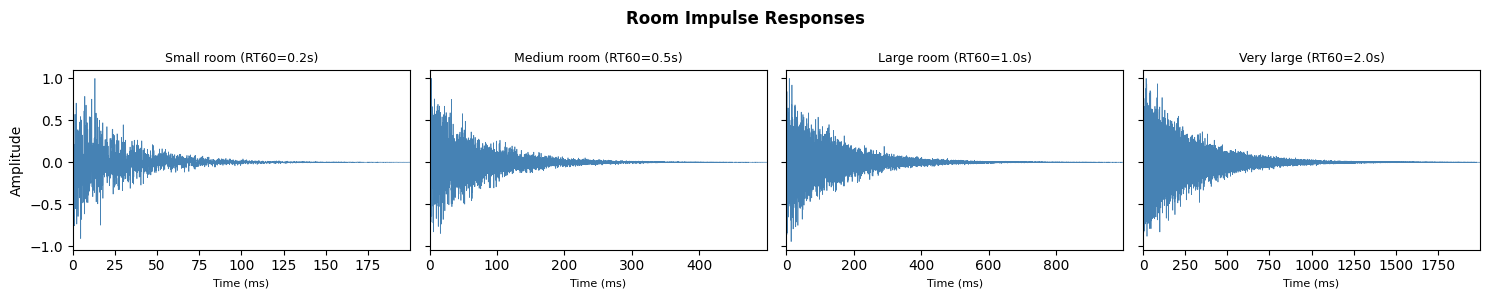

Saved: D:\pwr\biometria\lab\voice\results\task7_rir_waveforms.png


In [5]:
fig, axes = plt.subplots(1, len(RIR_CONFIGS), figsize=(15, 3), sharey=True)

for ax, (key, label, rt60, _) in zip(axes, RIR_CONFIGS):
    rir = rir_waveforms[key].squeeze().numpy()
    t   = np.arange(len(rir)) / SAMPLE_RATE * 1000  # ms
    ax.plot(t, rir, linewidth=0.5, color="steelblue")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Time (ms)", fontsize=8)
    ax.set_xlim(0, min(t[-1], rt60 * 1200))

axes[0].set_ylabel("Amplitude")
fig.suptitle("Room Impulse Responses", fontsize=12, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task7_rir_waveforms.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 4. Load model and enrolled embeddings

In [6]:
print("Loading ECAPA-TDNN model...")
model = load_model()

collection   = get_collection()
enrolled_ids = set(list_enrolled(collection))
print(f"Enrolled speakers: {len(enrolled_ids)}")

enrolled_cache: dict[str, np.ndarray] = _load_enrolled_embeddings_bulk(collection)
print(f"Loaded {len(enrolled_cache)} enrolled embeddings.")

if not enrolled_ids:
    raise RuntimeError("No speakers enrolled. Run src/enroll.py first.")

Loading ECAPA-TDNN model...


d:\pwr\biometria\venv\Lib\site-packages\speechbrain\utils\parameter_transfer.py:234: UserWarning: Requested Pretrainer collection using symlinks on Windows. This might not work; see `LocalStrategy` documentation. Consider unsetting `collect_in` in Pretrainer to avoid symlinking altogether.
  warnings.warn(
Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Enrolled speakers: 140
Loaded 140 enrolled embeddings.


## 5. Select test samples

In [7]:
N_GENUINE  = 50
N_IMPOSTOR = 50

rng = random.Random(RANDOM_SEED)

speaker_files: dict[str, list[Path]] = {}
for spk_dir in sorted(TEST_DIR.iterdir()):
    if spk_dir.is_dir() and spk_dir.name in enrolled_ids:
        wavs = sorted(spk_dir.rglob("*.wav"))
        if wavs:
            speaker_files[spk_dir.name] = wavs

speaker_ids = sorted(speaker_files.keys())
print(f"Speakers with test files: {len(speaker_ids)}")

genuine_pool = []
for spk_id in speaker_ids:
    for wav in speaker_files[spk_id]:
        genuine_pool.append((wav, spk_id, True))
rng.shuffle(genuine_pool)

impostor_pool = []
for spk_id in speaker_ids:
    other_ids = [s for s in speaker_ids if s != spk_id]
    if not other_ids:
        continue
    for imp_id in rng.sample(other_ids, min(2, len(other_ids))):
        impostor_pool.append((rng.choice(speaker_files[imp_id]), spk_id, False))
rng.shuffle(impostor_pool)

trials = genuine_pool[:N_GENUINE] + impostor_pool[:N_IMPOSTOR]
rng.shuffle(trials)

print(f"Genuine trials:  {sum(1 for t in trials if t[2])}")
print(f"Impostor trials: {sum(1 for t in trials if not t[2])}")
print(f"Total:           {len(trials)}")

Speakers with test files: 140
Genuine trials:  50
Impostor trials: 50
Total:           100


## 6. Reverb application and test conditions

In [8]:
# (key, label, rir_key)  –  rir_key=None means dry (no reverb)
CONDITIONS = [
    ("dry",        "Dry",                     None),
    ("small",      "Small room (RT60=0.2s)",  "small"),
    ("medium",     "Medium room (RT60=0.5s)", "medium"),
    ("large",      "Large room (RT60=1.0s)",  "large"),
    ("very_large", "Very large (RT60=2.0s)",  "very_large"),
]


def apply_reverb(speech: torch.Tensor, rir: torch.Tensor) -> torch.Tensor:
    """
    Convolve speech with RIR (linear convolution via FFT).
    Output is trimmed to original speech length and amplitude-normalized.
    """
    reverberant = torchaudio.functional.fftconvolve(speech, rir)
    reverberant  = reverberant[:, : speech.shape[1]]   # trim to original length

    # Preserve original peak amplitude
    peak_orig = speech.abs().max()
    peak_rev  = reverberant.abs().max()
    if peak_rev > 1e-10 and peak_orig > 1e-10:
        reverberant = reverberant * (peak_orig / peak_rev)
    return reverberant


def embed_waveform(model, waveform: torch.Tensor) -> np.ndarray:
    with torch.no_grad():
        emb = model.encode_batch(waveform)
    emb = emb.squeeze().cpu().numpy().astype(np.float32)
    norm = np.linalg.norm(emb)
    return emb / norm if norm > 0 else emb


print(f"Conditions: {[c[1] for c in CONDITIONS]}")

Conditions: ['Dry', 'Small room (RT60=0.2s)', 'Medium room (RT60=0.5s)', 'Large room (RT60=1.0s)', 'Very large (RT60=2.0s)']


## 7. Compute scores for all conditions

In [9]:
results: dict[str, dict] = {
    key: {"genuine": [], "impostor": []}
    for key, *_ in CONDITIONS
}

audio_cache: dict[Path, torch.Tensor] = {}

def get_cached(path: Path) -> torch.Tensor:
    if path not in audio_cache:
        audio_cache[path] = load_audio(path)
    return audio_cache[path]


print(f"Processing {len(trials)} trials × {len(CONDITIONS)} conditions...")

for i, (wav_path, enrolled_id, is_genuine) in enumerate(trials):
    if enrolled_id not in enrolled_cache:
        print(f"  [warn] {enrolled_id}: no enrolled embedding, skipping")
        continue

    enrolled_emb = enrolled_cache[enrolled_id]
    speech = get_cached(wav_path)
    bucket = "genuine" if is_genuine else "impostor"

    for key, label, rir_key in CONDITIONS:
        if rir_key is None:
            w = speech
        else:
            w = apply_reverb(speech, rir_waveforms[rir_key])

        score = float(np.dot(embed_waveform(model, w), enrolled_emb))
        results[key][bucket].append(score)

    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(trials)}...")

print("Done.")

Processing 100 trials × 5 conditions...
  25/100...
  50/100...
  75/100...
  100/100...
Done.


## 8. Metrics per condition

In [10]:
rows = []
print(f"{'Condition':<28} {'N gen':>6} {'N imp':>6} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")
print("-" * 72)

for key, label, rir_key in CONDITIONS:
    gen = np.array(results[key]["genuine"])
    imp = np.array(results[key]["impostor"])
    if len(gen) < 2 or len(imp) < 2:
        print(f"  {label}: not enough samples")
        continue

    eer, _ = compute_eer(gen, imp)
    m = compute_metrics_at_threshold(gen, imp, eer_threshold)
    rt60 = next((r[2] for r in RIR_CONFIGS if r[0] == rir_key), None) if rir_key else None
    row = {
        "key":          key,
        "label":        label,
        "rt60_s":       rt60,
        "rir_source":   rir_sources.get(rir_key, "none"),
        "n_genuine":    len(gen),
        "n_impostor":   len(imp),
        "eer_pct":      round(eer * 100, 2),
        "far_pct":      round(m["far"] * 100, 2),
        "frr_pct":      round(m["frr"] * 100, 2),
        "accuracy_pct": round(m["accuracy"] * 100, 2),
    }
    rows.append(row)
    print(
        f"  {label:<26} {len(gen):>6} {len(imp):>6}"
        f" {eer*100:>8.2f} {m['far']*100:>8.2f}"
        f" {m['frr']*100:>8.2f} {m['accuracy']*100:>8.2f}"
    )

print("-" * 72)
print(f"  [Task 1 baseline: EER={task1['eer_pct']:.2f}%  Acc={task1['accuracy_at_eer_pct']:.2f}%]")

Condition                     N gen  N imp     EER%     FAR%     FRR%     Acc%
------------------------------------------------------------------------
  Dry                            50     50     1.00     0.00     0.00   100.00
  Small room (RT60=0.2s)         50     50     1.00     0.00     0.00   100.00
  Medium room (RT60=0.5s)        50     50     1.00     0.00     0.00   100.00
  Large room (RT60=1.0s)         50     50     1.00     0.00     2.00    99.00
  Very large (RT60=2.0s)         50     50     1.00     0.00    10.00    95.00
------------------------------------------------------------------------
  [Task 1 baseline: EER=0.11%  Acc=99.89%]


## 9. EER & Accuracy vs. RT60

Shows how increasing reverberation time degrades performance.

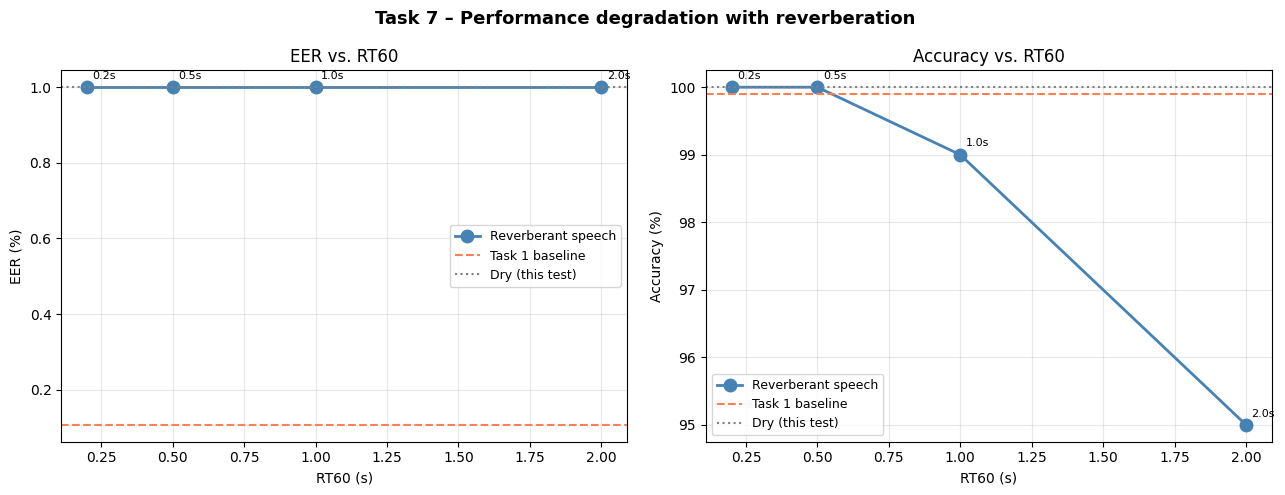

Saved: D:\pwr\biometria\lab\voice\results\task7_eer_vs_rt60.png


In [11]:
reverb_rows = [r for r in rows if r["rt60_s"] is not None]
rt60_vals   = [r["rt60_s"]      for r in reverb_rows]
eer_vals    = [r["eer_pct"]     for r in reverb_rows]
acc_vals    = [r["accuracy_pct"] for r in reverb_rows]
dry_row     = next((r for r in rows if r["rt60_s"] is None), None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, vals, ylabel, title, task1_val, dry_val in [
    (
        axes[0], eer_vals, "EER (%)", "EER vs. RT60",
        task1["eer_pct"],
        dry_row["eer_pct"] if dry_row else None,
    ),
    (
        axes[1], acc_vals, "Accuracy (%)", "Accuracy vs. RT60",
        task1["accuracy_at_eer_pct"],
        dry_row["accuracy_pct"] if dry_row else None,
    ),
]:
    ax.plot(
        rt60_vals, vals, "o-",
        color="steelblue", linewidth=2, markersize=9,
        label="Reverberant speech",
    )
    # Annotate each point with RT60 label
    for rt60, v in zip(rt60_vals, vals):
        ax.annotate(
            f"{rt60}s", (rt60, v),
            textcoords="offset points", xytext=(4, 6), fontsize=8,
        )
    ax.axhline(task1_val, color="coral", linestyle="--", linewidth=1.5, label="Task 1 baseline")
    if dry_val is not None:
        ax.axhline(dry_val, color="gray", linestyle=":",  linewidth=1.5, label="Dry (this test)")
    ax.set_xlabel("RT60 (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Task 7 – Performance degradation with reverberation", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task7_eer_vs_rt60.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 10. Score distributions

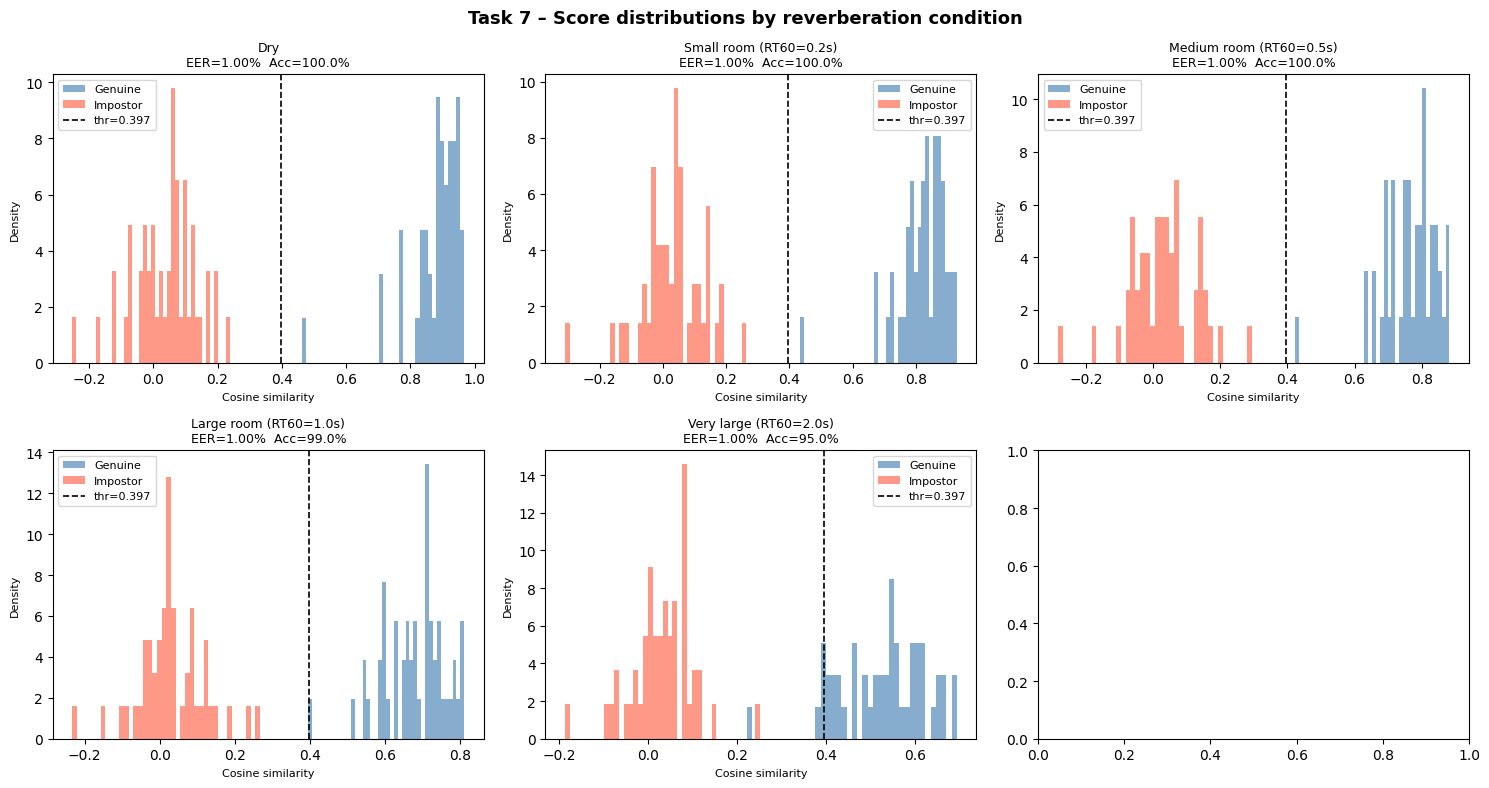

Saved: D:\pwr\biometria\lab\voice\results\task7_score_distributions.png


In [12]:
n_cond = len(CONDITIONS)
ncols  = 3
nrows  = (n_cond + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes_flat = axes.flat if nrows > 1 else [axes] if ncols == 1 else axes

for ax, (key, label, rir_key) in zip(axes_flat, CONDITIONS):
    gen = np.array(results[key]["genuine"])
    imp = np.array(results[key]["impostor"])

    ax.hist(gen, bins=40, alpha=0.65, color="steelblue", density=True, label="Genuine")
    ax.hist(imp, bins=40, alpha=0.65, color="tomato",    density=True, label="Impostor")
    ax.axvline(eer_threshold, color="black", linestyle="--", linewidth=1.2,
               label=f"thr={eer_threshold:.3f}")

    row_data = next((r for r in rows if r["key"] == key), None)
    if row_data and len(gen) >= 2 and len(imp) >= 2:
        eer_f, _ = compute_eer(gen, imp)
        ax.set_title(
            f"{label}\nEER={eer_f*100:.2f}%  Acc={row_data['accuracy_pct']:.1f}%",
            fontsize=9,
        )
    else:
        ax.set_title(label, fontsize=9)
    ax.set_xlabel("Cosine similarity", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=8)

# Hide unused axes
for ax in list(axes_flat)[n_cond:]:
    ax.set_visible(False)

fig.suptitle("Task 7 – Score distributions by reverberation condition", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task7_score_distributions.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 11. Comparison with Task 1

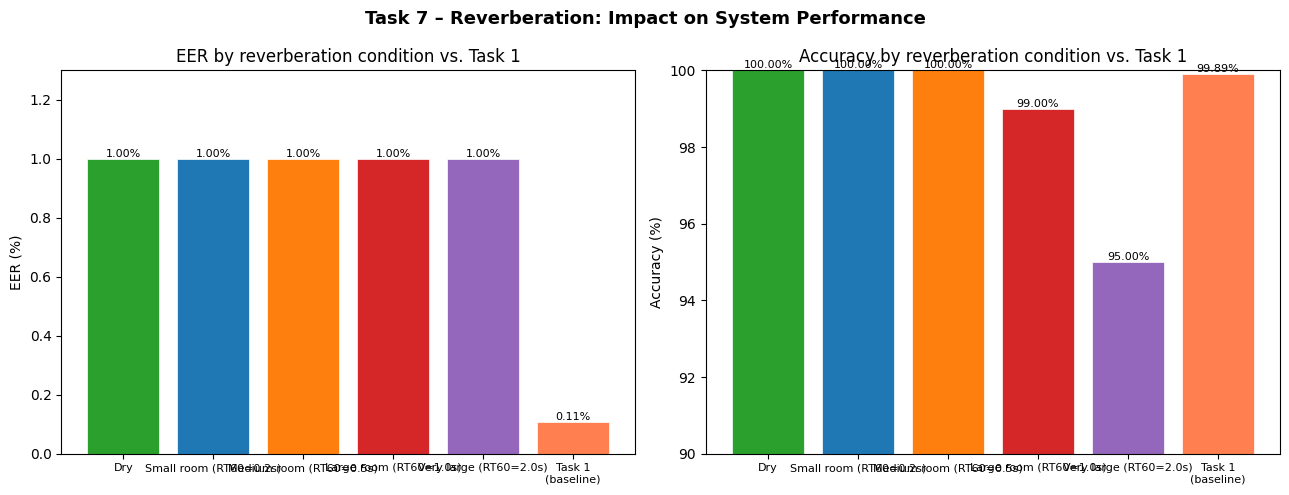

Saved: D:\pwr\biometria\lab\voice\results\task7_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels  = [r["label"] for r in rows] + ["Task 1\n(baseline)"]
eer_cmp = [r["eer_pct"]      for r in rows] + [task1["eer_pct"]]
acc_cmp = [r["accuracy_pct"] for r in rows] + [task1["accuracy_at_eer_pct"]]

palette = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "#9467bd", "coral"]
colors  = palette[:len(labels)]

for ax, vals, ylabel, title in [
    (axes[0], eer_cmp,  "EER (%)",      "EER by reverberation condition vs. Task 1"),
    (axes[1], acc_cmp,  "Accuracy (%)", "Accuracy by reverberation condition vs. Task 1"),
]:
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.2f%%", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8)

axes[0].set_ylim(0, max(eer_cmp) * 1.3)
axes[1].set_ylim(max(0, min(acc_cmp) - 5), 100)

fig.suptitle("Task 7 – Reverberation: Impact on System Performance", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task7_comparison.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 12. Save results

In [14]:
summary = {
    "task": 7,
    "description": "Reverberation via RIR convolution at RT60 = 0.2/0.5/1.0/2.0 s",
    "rir_sources": rir_sources,
    "n_trials": len(trials),
    "eer_threshold_used": eer_threshold,
    "per_condition": rows,
    "task1_eer_pct":      task1["eer_pct"],
    "task1_accuracy_pct": task1["accuracy_at_eer_pct"],
}

out_json = RESULTS_DIR / "task7_results.json"
with open(out_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "═" * 60)
print("  TASK 7 – REVERBERATION RESULTS")
print("═" * 60)
print(f"  {'Condition':<28} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")
print("  " + "-" * 56)
for r in rows:
    print(
        f"  {r['label']:<28} {r['eer_pct']:>8.2f}"
        f" {r['far_pct']:>8.2f} {r['frr_pct']:>8.2f} {r['accuracy_pct']:>8.2f}"
    )
print("  " + "-" * 56)
print(
    f"  {'Baseline (Task 1)':<28} {task1['eer_pct']:>8.2f}"
    f" {task1['far_at_eer_pct']:>8.2f} {task1['frr_at_eer_pct']:>8.2f} {task1['accuracy_at_eer_pct']:>8.2f}"
)
print("═" * 60)
print(f"\nJSON saved: {out_json}")


════════════════════════════════════════════════════════════
  TASK 7 – REVERBERATION RESULTS
════════════════════════════════════════════════════════════
  Condition                        EER%     FAR%     FRR%     Acc%
  --------------------------------------------------------
  Dry                              1.00     0.00     0.00   100.00
  Small room (RT60=0.2s)           1.00     0.00     0.00   100.00
  Medium room (RT60=0.5s)          1.00     0.00     0.00   100.00
  Large room (RT60=1.0s)           1.00     0.00     2.00    99.00
  Very large (RT60=2.0s)           1.00     0.00    10.00    95.00
  --------------------------------------------------------
  Baseline (Task 1)                0.11     0.14     0.07    99.89
════════════════════════════════════════════════════════════

JSON saved: D:\pwr\biometria\lab\voice\results\task7_results.json
